# Visualize semantic simialrity of paraphrases and reference
- Across multiple sets 
- using BERT embeddings and TSNE

In [1]:
import os
import sys


sys.path.append(os.path.abspath(".."))
from pathlib import Path
from genai_detection.config import CONFIG

path2results = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "paraphrasing"
    / "sem_sim_vis"
)
if not path2results.exists():
    path2results.mkdir(parents=True, exist_ok=True)

path2dump = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "dumps/impostor_naive_llm.json"
)

In [2]:
import json


def load_paraphrase_json(file_path, include_reference=True):
    """
    Reads a JSON file with the structure:
    {reference_text: {paraphraser_name: paraphrase, ...}, ...}

    Returns:
        all_text_lists: list of lists of texts
            - Each sublist corresponds to one reference and contains all paraphrases
        paraphraser_labels: list of same shape, optional labels
    """
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    all_text_lists = []
    paraphraser_labels = []

    for ref_text, paraphrases in data.items():
        texts = []
        labels = []

        if include_reference:
            texts.append(ref_text)
            labels.append("reference")

        for paraphraser, paraphrase_text in paraphrases.items():
            texts.append(paraphrase_text)
            labels.append(paraphraser)

        all_text_lists.append(texts)
        paraphraser_labels.append(labels)

    return all_text_lists, paraphraser_labels


all_texts, all_labels = load_paraphrase_json(path2dump, include_reference=True)

In [3]:
for i in range(len(all_texts)):
    print(f"Reference {i+1}:")
    for label, text in zip(all_labels[i], all_texts[i]):
        print(f"  {label}: {text[:60]}...")  # Print first 60 chars
    print("\n")
    if i >= 2:  # Limit output for brevity
        break

Reference 1:
  reference: One day the girl walked into her high school chemistry class...
  impostor_43_prompt0_openai-gpt-oss-120b: On a crisp weekday morning the young girl pushed open the do...
  impostor_44_prompt0_meta-llama-3.1-8b-instruct: As she entered her high school chemistry class one day, the ...
  impostor_47_prompt0_openai-gpt-oss-120b: On a seemingly ordinary morning, the girl pushed open the do...
  impostor_0_prompt0_qwen3-32b: 

On a typical school day, a young woman entered her high sc...
  impostor_1_prompt0_openai-gpt-oss-120b: On a seemingly ordinary morning, a teenage girl entered her ...
  impostor_2_prompt0_meta-llama-3.1-8b-instruct: As the girl entered her high school chemistry class, the tea...
  impostor_4_prompt0_qwen3-32b: 

One day, a young girl entered her high school chemistry cl...
  impostor_5_prompt0_openai-gpt-oss-120b: On a seemingly ordinary morning, the girl pushed open the do...
  impostor_6_prompt0_meta-llama-3.1-8b-instruct: In the midst of 

Batches:   0%|          | 0/71 [00:00<?, ?it/s]

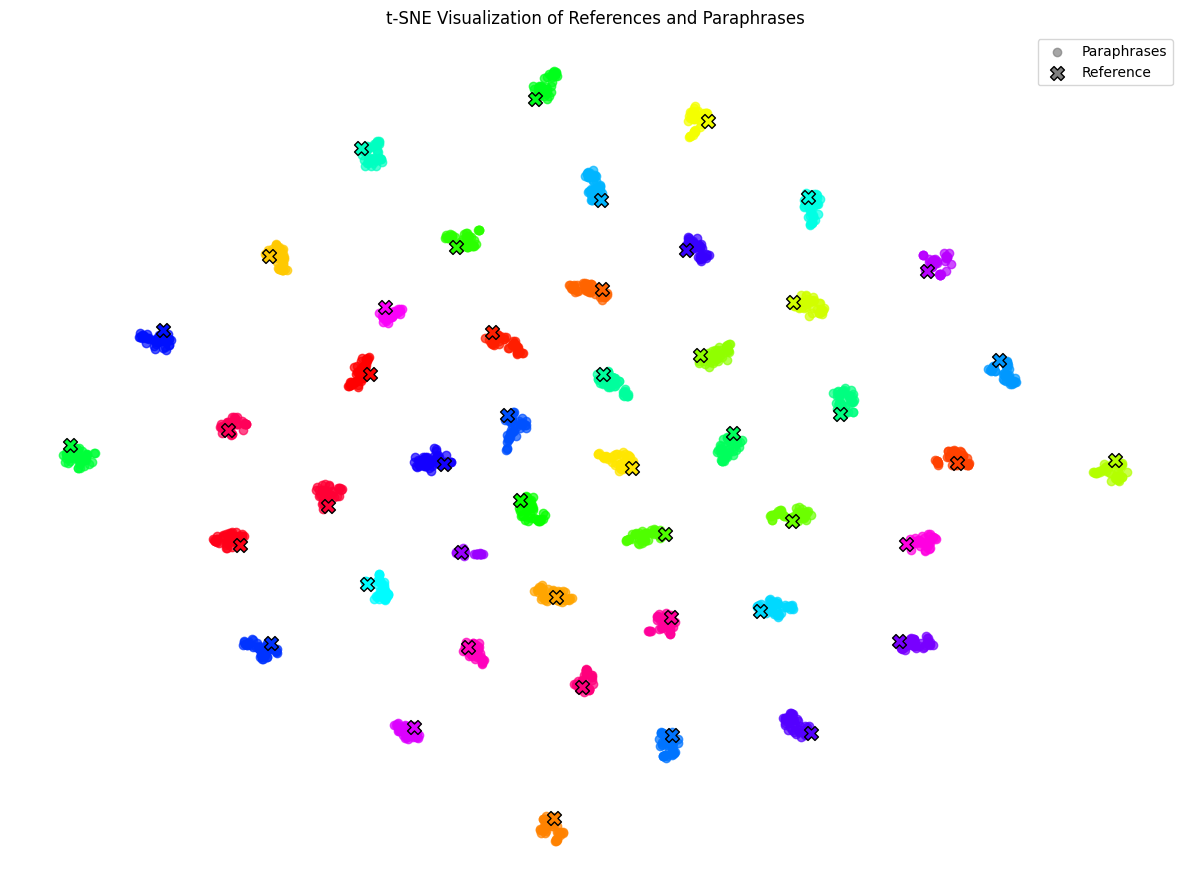

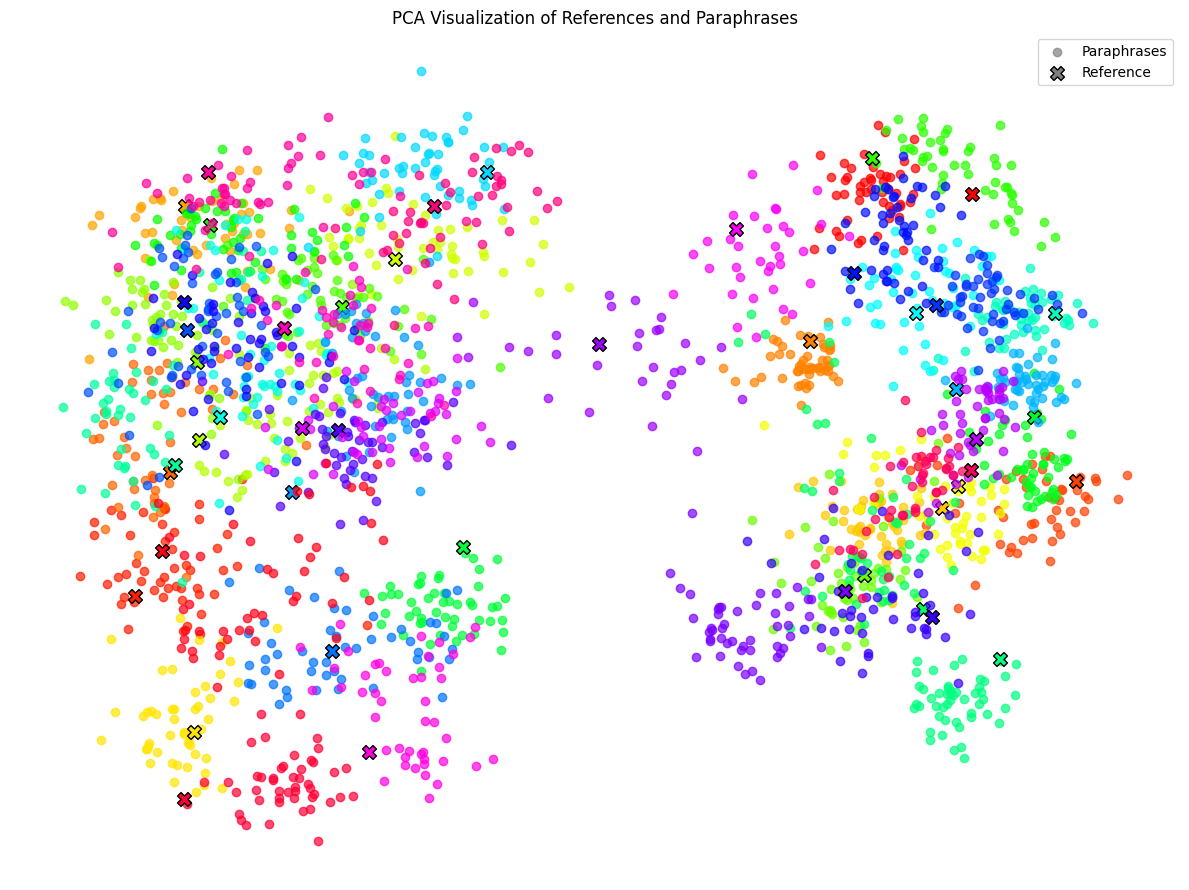

In [ ]:
from sentence_transformers import SentenceTransformer
import sklearn
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np


def get_distinct_colors(n):
    """Generate n distinct colors using HSV space"""
    return plt.cm.hsv(np.linspace(0, 1, n))


def plot_paraphrase_dim_red(
    all_text_lists,
    model_name="all-MiniLM-L6-v2",
    random_state=42,
    figsize=(12, 9),
    annotate=False,
):
    # Flatten texts and track group indices
    texts = []
    group_indices = []
    for i, group in enumerate(all_text_lists):
        texts.extend(group)
        group_indices.extend([i] * len(group))

    # Compute embeddings
    model = SentenceTransformer(model_name)
    embeddings = model.encode(texts, show_progress_bar=True)

    # t-SNE projection
    tsne = TSNE(
        n_components=2, random_state=random_state, init="random", learning_rate="auto"
    )
    pca = sklearn.decomposition.PCA(n_components=2)

    for reduction, red_name in zip([tsne, pca], ["t-SNE", "PCA"]):
        embeddings_2d = reduction.fit_transform(embeddings)

        n_groups = len(all_text_lists)
        colors_list = get_distinct_colors(n_groups)

        plt.figure(figsize=figsize)

        for i in range(n_groups):
            idxs = [j for j, g in enumerate(group_indices) if g == i]
            ref_idx = idxs[0]
            para_idxs = idxs[1:]

            # Paraphrases
            plt.scatter(
                embeddings_2d[para_idxs, 0],
                embeddings_2d[para_idxs, 1],
                color=colors_list[i],
                alpha=0.7,
            )

            # Reference
            plt.scatter(
                embeddings_2d[ref_idx, 0],
                embeddings_2d[ref_idx, 1],
                color=colors_list[i],
                marker="X",
                edgecolors="black",
                s=100,
            )

            if annotate:
                for j in idxs:
                    plt.annotate(
                        texts[j][:30] + "..." if len(texts[j]) > 30 else texts[j],
                        (embeddings_2d[j, 0], embeddings_2d[j, 1]),
                        fontsize=8,
                        alpha=0.7,
                    )

        # Legend logic
        if n_groups <= 5:
            # Create legend showing both paraphrases and reference per group
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            plt.legend(by_label.values(), by_label.keys(), fontsize=10)
        else:
            # Dummy legend
            plt.scatter([], [], color="gray", alpha=0.7, label="Paraphrases")
            plt.scatter(
                [],
                [],
                color="gray",
                marker="X",
                s=100,
                edgecolors="black",
                label="Reference",
            )
            plt.legend(fontsize=10)

        plt.title(f"{red_name} Visualization of References and Paraphrases")
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(path2results / f"paraphrase_vis_{red_name}.svg", dpi=300)
        plt.show()

    return embeddings_2d


embeddings_2d = plot_paraphrase_dim_red(all_texts, annotate=False)